## **1. Download Data**
---

In [ ]:
import os
import shutil
import kagglehub
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
# Download the dataset
path = kagglehub.dataset_download('stoicstatic/face-recognition-dataset/versions/10')
print(f"Org path: {path}")
print(f"Contains: {os.listdir(path)}")

100%|██████████| 181M/181M [00:09<00:00, 20.6MB/s] 

Extracting files...


Org path: C:\Users\nguye\.cache\kagglehub\datasets\stoicstatic\face-recognition-dataset\versions\10
Contains: ['Extracted Faces', 'Face Data']


In [4]:
# Rebase the dataset
os.makedirs('dataset/downloaded', exist_ok=True)
for ds in os.listdir(path):
    shutil.move(os.path.join(path, ds), 'dataset/downloaded')
shutil.rmtree(path)

## **2. Prepare Data (Optional)**
---

In [7]:
# Constraints
DOWNLOAD_DIR  = 'dataset/downloaded'
PEOPLE_DIR    = 'dataset/downloaded/Face Data/Face Dataset'
FACE_DIR      = 'dataset/downloaded/Extracted Faces/Extracted Faces'

PROCESSED_DIR = 'dataset/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [8]:
# Get info
def dataset_info(dataset_path):
    print(f"Dataset: {os.path.basename(dataset_path)}")
    print(f"Length : {len(os.listdir(dataset_path))}")
    
    img_shape = set()
    img_cnt   = ppl_cnt = 0
    for person_id in tqdm(os.listdir(dataset_path), desc=f"Counting {os.path.basename(dataset_path)}..."):
        person_path = os.path.join(dataset_path, person_id)
        
        if os.path.isdir(person_path):
            ppl_cnt += 1
            
            for img_name in os.listdir(person_path):
                img_path = os.path.join(person_path, img_name)
                
                if os.path.isfile(img_path):
                    img = cv2.imread(img_path)
                    
                    if img is not None:
                        img_shape.add(img.shape)
                        img_cnt += 1
                        
    print(f"Total images: {img_cnt}\nTotal people: {ppl_cnt}\nImage shape: {img_shape}")
    

def person_info(person_id, dataset_path):
    person_path = os.path.join(dataset_path, person_id)
    
    n = len(os.listdir(person_path))
    c = 5
    r = n // c + (n % c > 0)
    
    _, axes = plt.subplots(r, c, figsize=(c * 2, r* 2), squeeze=False)
    axes = axes.flatten()
    
    for img_name, ax in zip(os.listdir(person_path), axes[:n]):
        img = cv2.imread(os.path.join(person_path, img_name))
        
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(img_name)
            ax.axis('off')
            
    for ax in axes[n:]:
        ax.axis('off')
        
    plt.suptitle(f"Person: {person_id}")
    plt.tight_layout()
    plt.show()

In [9]:
# Rebuild dataset
def copy_dataset(dataset_path, dest_path):
    for person_id in tqdm(os.listdir(dataset_path), desc=f"Copying {os.path.basename(dataset_path)}..."):
        person_path = os.path.join(dataset_path, person_id)
        
        if os.path.isdir(person_path):
            dest_person_path = os.path.join(dest_path, person_id)
            os.makedirs(dest_person_path, exist_ok=True)
            
            dest_person_cnt = len(os.listdir(dest_person_path))
            for i, img_name in enumerate(os.listdir(person_path)):
                img_path = os.path.join(person_path, img_name)

                if os.path.isfile(img_path):
                    _, ext        = os.path.splitext(img_name)
                    dest_img_name = f"{person_id}_{(dest_person_cnt + i):04d}{ext.lower()}"
                    dest_img_path = os.path.join(dest_person_path, dest_img_name)
                    shutil.copy(img_path, dest_img_path)

Dataset: Face Dataset
Length : 1680


Counting Face Dataset...:   0%|          | 0/1680 [00:00<?, ?it/s]

Total images: 8204
Total people: 1680
Image shape: {(250, 250, 3)}


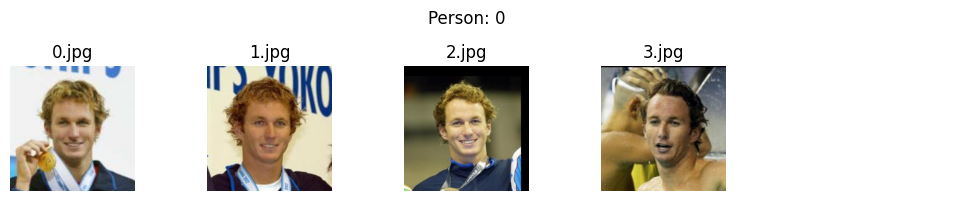

In [10]:
dataset_info(PEOPLE_DIR)
person_info('0', PEOPLE_DIR)

Dataset: Extracted Faces
Length : 1324


Counting Extracted Faces...:   0%|          | 0/1324 [00:00<?, ?it/s]

Total images: 6107
Total people: 1324
Image shape: {(128, 128, 3)}


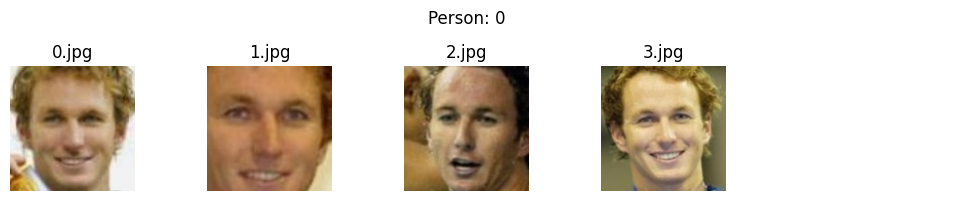

In [11]:
dataset_info(FACE_DIR)
person_info('0', FACE_DIR)

Copying Face Dataset...:   0%|          | 0/1680 [00:00<?, ?it/s]

Copying Extracted Faces...:   0%|          | 0/1324 [00:00<?, ?it/s]

Dataset: processed
Length : 1680


Counting processed...:   0%|          | 0/1680 [00:00<?, ?it/s]

Total images: 14311
Total people: 1680
Image shape: {(250, 250, 3), (128, 128, 3)}


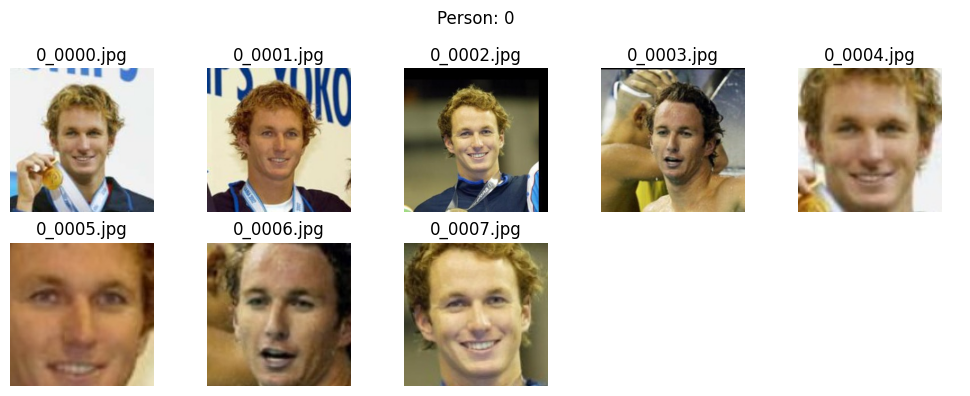

In [12]:
copy_dataset(PEOPLE_DIR, PROCESSED_DIR)
copy_dataset(FACE_DIR, PROCESSED_DIR)

dataset_info(PROCESSED_DIR)
person_info('0', PROCESSED_DIR)

In [ ]:
# import cv2
# import numpy as np
# from retinaface import RetinaFace

# class FaceDetector:
#     def __init__(self, threshold: float = 0.9, upscale: bool = True):
#         self.threshold = threshold
#         self.upscale   = upscale
#         self.model     = RetinaFace.build_model()

#     def detect(self, frame: np.ndarray) -> list[dict]:
#         rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if frame.shape[2] == 3 else frame
#         faces = RetinaFace.detect_faces(rgb, self.threshold, self.model, self.upscale)

#         results = []
#         for face_id, face in faces.items():
#             results.append({
#                 'facial_area': face['facial_area'],
#                 'landmarks'  : face['landmarks'],
#                 'score'      : face['score']
#             })
#         return results

#     def draw_on(self, frame: np.ndarray, faces: list[dict]) -> np.ndarray:
#         for face in faces:
#             x1, y1, x2, y2 = face['facial_area']
#             cv2.rectangle(frame, (x1,y1), (x2,y2), color=(0,255,0), thickness=2)
            
#             for lm in face['landmarks'].values():
#                 cv2.circle(frame, (int(lm[0]), int(lm[1])), radius=2, color=(0,0,255), thickness=-1)
                
#         return frame


# === Ví dụ sử dụng với webcam ===
# if __name__ == "__main__":
#     cap      = cv2.VideoCapture(0)
#     detector = FaceDetector(threshold=0.9, upscale=True)

#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         faces = detector.detect(frame)
#         frame = detector.draw_on(frame, faces)

#         cv2.imshow('Real-time Face Detection', frame)
#         if cv2.waitKey(1) & 0xFF == 27: # 'ESC'
#             break

#     cap.release()
#     cv2.destroyAllWindows()